Le module keras permet de définir facilement des réseaux de neurones en les décrivant couche par couche.
Pour l’instant nous définissons les poids à la main, en attendant de voir plus tard comment les calculer avec la machine. Pour commencer nous allons créer le réseau de neurones correspondant à la figure suivante

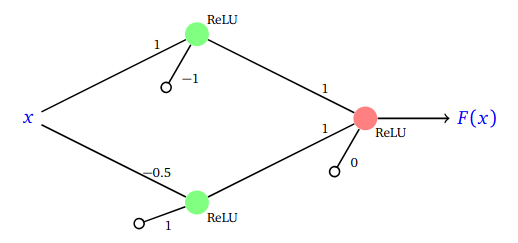

#  Module keras de tensorflow

En plus d’importer le module numpy (abrégé par np), il faut importer le sous-module keras du module tensorflow et quelques outils spécifiques :

In [19]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

##  Couches de neurone
Nous allons définir l’architecture d’un réseau très simple, en le décrivant couche par couche.

In [20]:
# Architecture du réseau
modele = Sequential()

# Couches de neurones
modele.add(Dense(2, input_dim=1, activation='relu'))
modele.add(Dense(1, activation='relu'))

/home/logan/.local/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Explications :

• Notre réseau s’appelle modele, il est du type Sequential, c’est-à-dire qu’il va être décrit par une suite de couches les unes à la suite des autres.  
• Chaque couche est ajoutée à la précédente par modele.add(). L’ordre d’ajout est donc important.  
• Chaque couche est ajoutée par une commande :
**modele.add(Dense(nb_neurones, activation=ma_fonction))**  
• Une couche de type Dense signifie que chaque neurone de la nouvelle couche est connectée à toutes les sorties des neurones de la couche précédente.

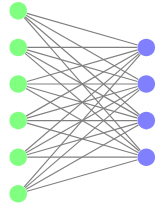

 Pour chaque couche, il faut préciser le nombre de neurones qu’elle contient. S’il y a $n$ neurones alors la couche renvoie $n$ valeurs en sortie. On rappelle qu’un neurone renvoie la même valeur de sortie vers tous les neurones de la couche suivante.


Pour la première couche, il faut préciser le nombre de valeurs en entrée (par l’option **input_dim = ...**). Dans le code ici, on a une entrée d’une seule variable. Sur la figure ci-dessous un exemple d’une
entrée de dimension 3.


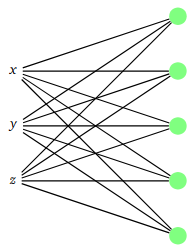

Pour les autres couches, le nombre d’entrées est égal au nombre de sorties de la couche précédente. Il
n’est donc pas nécessaire de le préciser.

Pour chaque couche, il faut également préciser une fonction d’activation (c’est la même pour tous les
neurones d’une même couche). Plusieurs fonctions d’activation sont prédéfinies :
'relu' (ReLU), 'sigmoid' (σ), 'linear' (identité).

Nous verrons plus tard comment définir notre propre fonction d’activation, comme par exemple la fonction marche de Heaviside

Notre exemple ne possède qu’une entrée et comme il n’y a qu’un seul neurone sur la dernière couche alors
il n’y a qu’une seule valeur en sortie. Ainsi notre réseau va définir une fonction $$F:\mathbb{R} → \mathbb{R}, x→F(x)$$.
Mais attention, pour l’instant ce n’est qu’un modèle de réseau puisque nous n’avons pas fixé de poids.

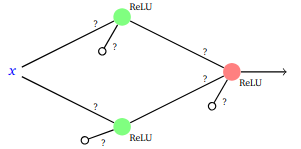

Pour vérifier que tout va bien jusque là, on peut exécuter la commande
**modele.summary()**
qui affiche un résumé des couches et du nombre de poids à définir. Appliquer cette commande et observer le résultat.

In [21]:
modele.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

##  Les poids

Lors de la définition d’un réseau et de la structure de ses couches, des poids aléatoires sont attribués à
chaque neurone. La démarche habituelle est ensuite d’entraîner le réseau, automatiquement, afin qu’il
trouve de « bons » poids. Mais pour l’instant, nous continuons de fixer les poids de chaque neurone à la
main.
La commande pour fixer les poids est **set_weights()**.
Nous allons utiliser les poids suivant

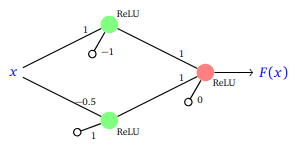

Voici la définition des poids de la première couche, numérotée 0 :

In [22]:
# Couche 0
coeff = np.array([[1.,-0.5]])
biais = np.array([-1,1])
poids = [coeff,biais]
modele.layers[0].set_weights(poids)

Définir les poids de la couche numéro 1 :

In [23]:
# Couche 1
coeff = np.array([[1.],[1.]])
biais = np.array([0])
poids = [coeff,biais]
modele.layers[1].set_weights(poids)

Voici quelques précisions concernant la commande **set_weights()**. Son utilisation n’est pas très aisée.

• Les poids sont définis pour tous les éléments d’une couche, par une commande **set_weights(poids)**.

• Les poids sont donnés sous la forme d’une liste : **poids = [coeff,biais]**.

• Les biais sont donnés sous la forme d’un vecteur de biais (un pour chaque neurone).

• Les coefficients sont donnés sous la forme d’un tableau à deux dimensions. Ils sont définis par entrée.

Attention, la structure n’est pas naturelle (nous y reviendrons).



À vous : dire ce que renvoie l'instruction **modele.layers[0].get_weights()** et à quoi correspond elle?

In [24]:
print(modele.layers[0].get_weights())

[array([[ 1. , -0.5]], dtype=float32), array([-1.,  1.], dtype=float32)]


L'instruction retourne les poids et les biais de la première couche du réseau de neurones.  
Les poids sont représentés par une matrice (dans ce cas, une matrice 1x2) et les biais sont représentés par un vecteur (dans ce cas, un vecteur de taille 2).  
Ces valeurs ont été définit précédemment avec l'instruction `modele.layers[0].set_weight(poids)`, où les poids étaient [[1., -0.5]] et les biais étaient [-1, 1]

## Évaluation

Comment utiliser le réseau ? C’est très simple avec predict(). Notre réseau définit une fonction $x→F(x)$.
L’entrée correspond donc à un réel et la sortie également. Voici comment faire

In [25]:
# entree = np.array([VALEUR])
# sortie = modele.predict(entree)

À vous. Donner la sortie prédite. Vérifier le calcule à la main en calculant la sortie de chaque neurone.

In [26]:
entree = np.array([3])
sortie = modele.predict(entree)
print(sortie)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[[2.]]


Soit la fonction $ReLU(x)$ est définit par:

$$
ReLU(x) = {}
$$

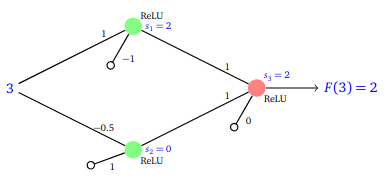

# Visualisation

Afin de tracer le graphe de la fonction $F:\mathbb{R}→\mathbb{R}$, on peut calculer d’autres valeurs :

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


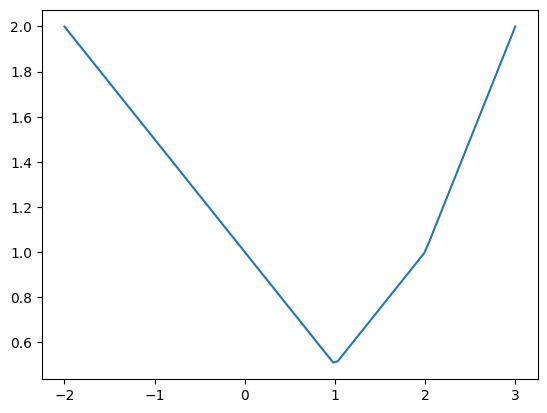

In [27]:
import matplotlib.pyplot as plt
liste_x = np.linspace(-2, 3, num=100)
entree = np.array([[x] for x in liste_x])
sortie = modele.predict(entree)
liste_y = np.array([y[0] for y in sortie])
plt.plot(liste_x,liste_y)
plt.show()

Commentez le graphique ci-dessus

On remarque que les valeurs allant de -2 à 1 sont extrêmements linéaires et tendent vers 0, tandis que de 1 à 3 les valeurs coient mais sont moins linéaires 

# Créer votre perceptron

Prédire la sortie pour $x=3$ et affichez sur la plage de valeur $x\in[-2,3]$ les sortie du perceptron suivant

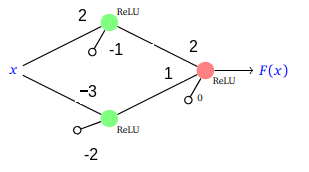

In [28]:
# Architecture du réseau
perceptron = Sequential()

# Couches de neurones
perceptron.add(Dense(2, input_dim=1, activation='relu'))
perceptron.add(Dense(1, activation='relu'))

# On définit les neurones de la couche 0
coeff = np.array([[2.,-3.]])
biais = np.array([-1., -2.])
poids = [coeff,biais]
perceptron.layers[0].set_weights(poids)

# On définit les neurones de la couche 1
coeff = np.array([[2.],[1.]])
biais = np.array([0])
poids = [coeff,biais]
perceptron.layers[1].set_weights(poids)

perceptron.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


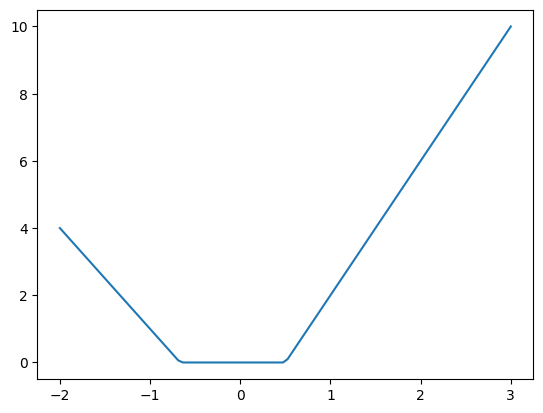

In [29]:
# Visualisation
liste_x = np.linspace(-2, 3, num=100)
entree = np.array([[x] for x in liste_x])
sortie = perceptron.predict(entree)
liste_y = np.array([y[0] for y in sortie])
plt.plot(liste_x,liste_y)
plt.show()

Changer le coefficient du second neurone de la première couche (-3) par 3. Commenter le changement sur la courbe

In [30]:
# On modifie le coef du second neurones de la première couche (-3) par 3
coeff = np.array([[2.,3.]])
biais = np.array([-1., -2.])
poids = [coeff,biais]
perceptron.layers[0].set_weights(poids)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


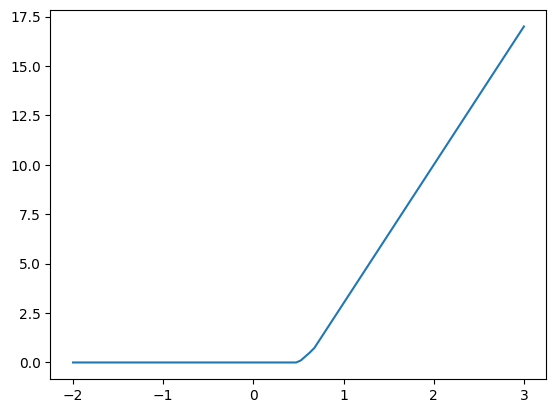

In [31]:
# Visualisation
liste_x = np.linspace(-2, 3, num=100)
entree = np.array([[x] for x in liste_x])
sortie = perceptron.predict(entree)
liste_y = np.array([y[0] for y in sortie])
plt.plot(liste_x,liste_y)
plt.show()

Concrètement, la première couche calcule deux soties avec $ReLU$:
- neurone 1 : $\max{(0,2x-1)}$
- neurone 2 : $\max{(0,-3x-2)}$ puis $\max{(0,3x-2)}$

Avec -3, le second neurone devient positif seulement quand $x < -2/3$. Il agit donc sur la partie gauche du groupe. Avec 3, il devient positif seulement quand $x > 2/3$. Il agit donc sur la partie droite.

Prédire la sortie pour $x=3$ et affichez sur la plage de valeur $x\in[-2,3]$ les sortie du perceptron suivant

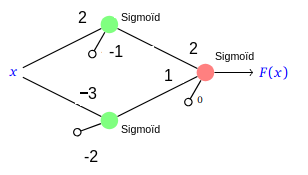

In [ ]:
# Architecture du réseau
modele = Sequential()

# Couches de neurones
modele.add(Dense(2, input_dim=1, activation='sigmoid'))
modele.add(Dense(1, activation='sigmoid'))

# On définit les neurones de la couche 0
coeff = np.array([[2.,-1.]])
biais = np.array([-3., -2.])
poids = [coeff,biais]
modele.layers[0].set_weights(poids)

# On définit les neurones de la couche 1
coeff = np.array([[2.],[1.]])
biais = np.array([0])
poids = [coeff,biais]
modele.layers[1].set_weights(poids)

entree = np.array([[3.]])
modele.predict(entree)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[0.87122583]], dtype=float32)

## Réseaux pour variables multi dimensionnelles

Essayons avec une variable de dimension 2. Nous remplaçons le terme 'sigmoïd' par $\sigma$ par souci de lecture.

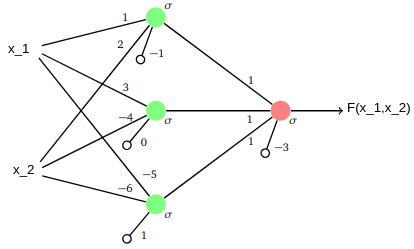

In [33]:
# Architecture du réseau
modele = Sequential()
# Couches de neurones
modele.add(Dense(3, input_dim=2, activation='sigmoid'))
modele.add(Dense(1, activation='sigmoid'))

La première couche possède 3 neurones, chacun ayant deux entrées. La seconde couche n’a qu’un seul neurone (qui a automatiquement 3 entrées). La fonction d’activation est partout la fonction $\sigma$

In [34]:
# Couche 0
coeff = np.array([[1.0,3.0,-5.0],[2.0,-4.0,-6.0]])
biais = np.array([-1.0,0.0,1.0])
poids = [coeff,biais]
modele.layers[0].set_weights(poids)

Remarquez que les poids ne sont pas définis neurone par neurone, mais par entrée : d’abord les poids de la première entrée pour chaque neurone, puis les poids de la seconde entrée pour chaque neurone, etc.

Définir la couche 1

In [35]:
# Couche 1
coeff = np.array([[1.],[1.],[1.]])
biais = np.array([-3])
poids = [coeff,biais]
modele.layers[1].set_weights(poids)

Donner la sortie associée à la variable (7,−5)

In [36]:
entree = np.array([[7,-5]])
modele.predict(entree)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[0.12303182]], dtype=float32)

 Voici comment tracer le graphe de $F : \mathbb{R}^2 → \mathbb{R}$.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


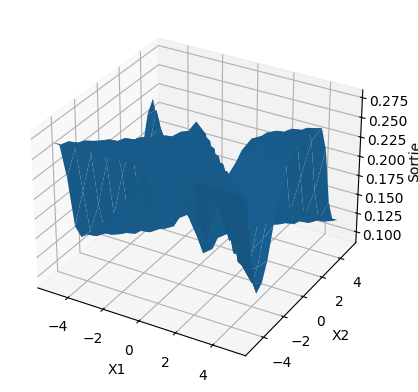

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
VX1 = np.linspace(-5, 5, 20)
VX2 = np.linspace(-5, 5, 20)
X1,X2 = np.meshgrid(VX1, VX2)
entree = np.c_[X1.ravel(), X2.ravel()]
sortie = modele.predict(entree)
Y = sortie.reshape(X1.shape)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X1, X2,  Y)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Sortie')
plt.show()

Commenter chaque ligne du code ci-dessous en expliquant son utilité

# Codage de sa propre fonction d'activation

Les fonction d'activations $H$ type linear ($f(x)=ax+b$) ou Heaviside ne sont pas directement implémenter sous Keras. Voici comment coder votre propre fonction Heaviside par exemple

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from keras.utils import get_custom_objects

# Définir la fonction d'activation Heaviside en utilisant TensorFlow
from tensorflow.keras import backend as K


def heaviside(x):
	""" Définis la fonction de Heaviside qui n'est pas défini
	par défaut dans keras. A utiliser comme fonction
	d'activiation lors de la définition d'une couche par exemple
	    modele.add(Dense(4,activation=heaviside))
	Attention il n'y a pas de guillemet ici."""
	return tf.where(x >= 0 , 1 , 0)


Coder le perceptron suivant et afficher la sortie pour $x\in[-2;3]$

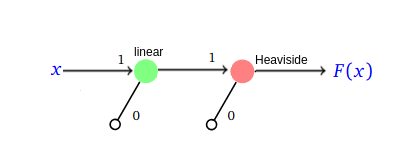

In [55]:
modeleHS = Sequential()

modeleHS.add(Dense(1, input_dim=1, activation='relu'))
modeleHS.add(Dense(1, activation=heaviside))

# Couche 0
coef = np.array([[1.]])
biais = np.array([[0.]])
modeleHS.layers[0].set_weights([np.array([[1.]]), np.array([0.])])

# Couche 1
coef = np.array([[1.]])
biais = np.array([[0.]])
modeleHS.layers[1].set_weights([np.array([[1.]]), np.array([0.])])

modeleHS.summary()


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
entree1 = np.array([[-2]])
print(modeleHS.predict(entree1))

entree2 = np.array([[3]])
print(modeleHS.predict(entree2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[1]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[1]]


# Approximation de fonction

Nous allons montrer comment approximer une fonction à l'aide d'un réseau de neurone.
Définissons une fonction arbitrairement

In [64]:
def f(x):
  return np.cos(2*x) + x*np.sin(3*x) + x**0.5

Affichons cette fonction pour l'intervalle $[0;10]$ :

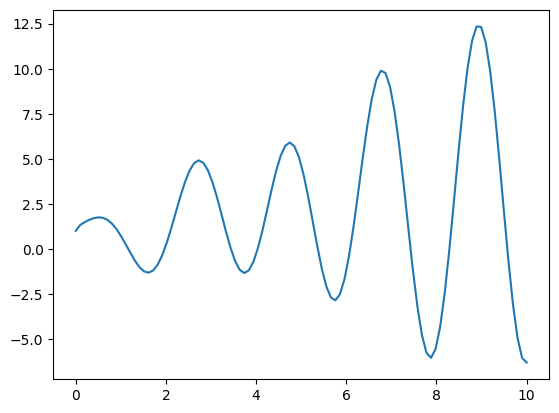

In [65]:
import matplotlib.pyplot as plt
a=0
b = 10
liste_x = np.linspace(a, b, num=100)
liste_y = f(liste_x)
plt.plot(liste_x,liste_y)
plt.show()

Essayer d'approximer cette fonction à l'aide d'un ensemble de couche (éventuellement en série) de type Heavyside et linéaire

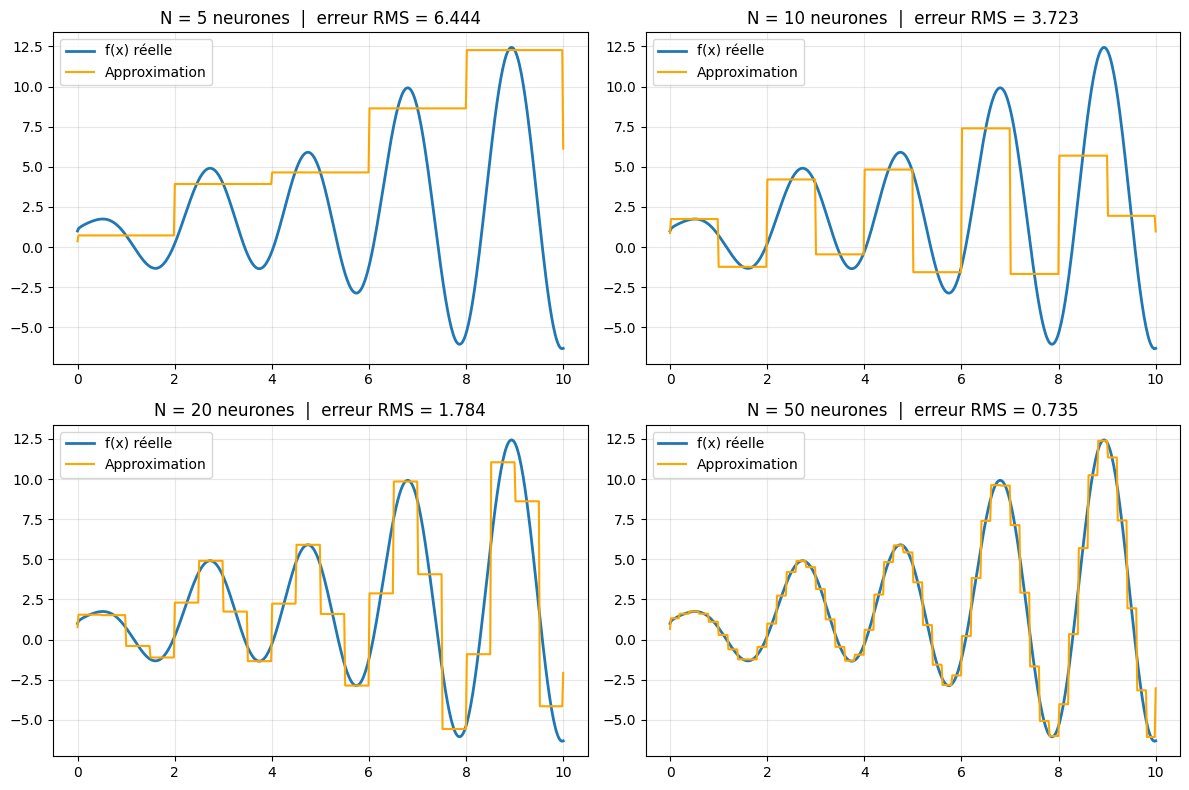

In [68]:
# Approximer la fonction f à l'aide d'un ensemble de couches de type Heavyside et linéaire

# --- La fonction cible ---
def f(x):
    return np.cos(2*x) + x*np.sin(3*x) + x**0.5

# --- Fonction de Heaviside (déjà dans numpy) ---
# np.heaviside(x - c, 0.5) vaut 0 si x<c, 1 si x>c

# --- Couche Heaviside : N neurones avec seuils réguliers ---
def heaviside_layer(x, thresholds):
    """Retourne une matrice (len(x), N) d'activations"""
    return np.array([np.heaviside(x - t, 0.5) for t in thresholds]).T

# --- Approximation par créneaux ---
def approximate(x, N):
    # 1) Définir les seuils (= positions des neurones)
    thresholds = np.linspace(0, 10, N + 1)
    dx = 10 / N

    # 2) Calculer les poids : valeur de f au centre de chaque créneau
    centers = thresholds[:-1] + dx / 2
    weights = f(centers)  # couche linéaire = juste ces poids

    # 3) Construire l'approximation : somme de créneaux pondérés
    #    créneau_i(x) = H(x - x_i) - H(x - x_{i+1})
    result = np.zeros_like(x, dtype=float)
    for i in range(N):
        creneau = (np.heaviside(x - thresholds[i],   0.5)
                 - np.heaviside(x - thresholds[i+1], 0.5))
        result += weights[i] * creneau

    return result

# --- Visualisation pour différents N ---
x = np.linspace(0, 10, 500)
y_real = f(x)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, N in zip(axes.flat, [5, 10, 20, 50]):
    y_approx = approximate(x, N)
    erreur = np.sqrt(np.mean((y_real - y_approx)**2))

    ax.plot(x, y_real,   label='f(x) réelle',       linewidth=2)
    ax.plot(x, y_approx, label='Approximation',      linewidth=1.5, color='orange')
    ax.set_title(f'N = {N} neurones  |  erreur RMS = {erreur:.3f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Apprentissage automatique des poids

La librairie keras de tensorflow vous permet d'apprendre automatiquement les poids à l'aide d'un optimiseur.
Voici un exemple d'utilisation

/home/logan/.local/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


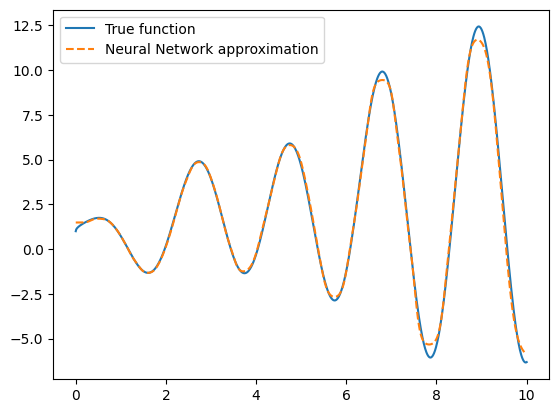

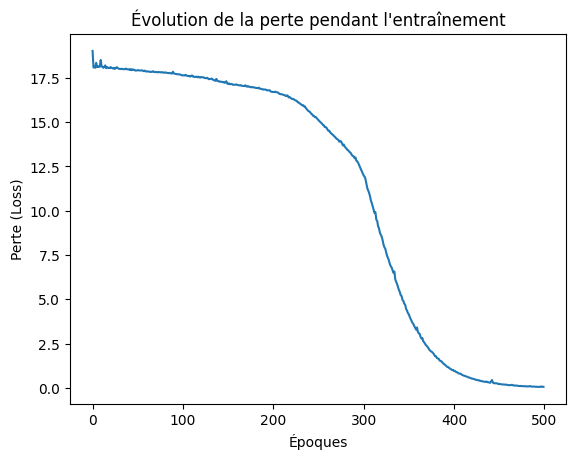

In [66]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Fonction à approximer
def f(x):
    return np.cos(2*x) + x*np.sin(3*x) + np.sqrt(x)

# Générer des données d'entraînement
x_train = np.linspace(0, 10, 1000)  # Entrées (1000 points entre 0 et 10)
y_train = f(x_train)  # Sorties correspondantes

x_train_scaled = x_train
y_train_scaled = y_train

# Architecture du modèle améliorée
modele = Sequential()

# Couches du modèle
modele.add(Dense(128, input_dim=1, activation='tanh'))  # Première couche avec 128 neurones et activation 'tanh'
modele.add(Dense(64, activation='tanh'))
modele.add(Dense(1, activation='linear'))  # Sortie avec 1 neurone et activation linéaire

# Compiler le modèle
modele.compile(optimizer='adam', loss='mean_squared_error')

# Entraîner le modèle
history = modele.fit(x_train_scaled, y_train_scaled, epochs=500, batch_size=32, verbose=0)

# Prédire avec le modèle entraîné
y_pred_scaled = modele.predict(x_train_scaled)

y_pred = y_pred_scaled

# Afficher les résultats
plt.plot(x_train, y_train, label='True function')
plt.plot(x_train, y_pred, label='Neural Network approximation', linestyle='dashed')
plt.legend()
plt.show()

# Afficher l'historique des pertes (loss) au fil des époques
plt.plot(history.history['loss'])
plt.title('Évolution de la perte pendant l\'entraînement')
plt.xlabel('Époques')
plt.ylabel('Perte (Loss)')
plt.show()


Décrire l'architecture du réseau

Modifier la fonction telle que $f(x)=cos(2*x) + x*sin(3*x)$
et comparer l'approximation